# 01 — Pandas EDA (Gold/Dashboard Layer)

This notebook explores business behavior using curated warehouse tables (gold + dashboard), while still keeping a quick raw-level sanity view.

## Data sources used
- Gold: `gold_fact_orders`, `gold_fact_order_items`, `gold_fact_order_payments`, `gold_fact_order_reviews`, `gold_customer_delivered_orders`
- Dashboard marts: `dash_kpi_monthly`, `dash_kpi_daily`, `dash_retention_snapshot`, `dash_retention_monthly`, `dash_category_monthly`

## Sections
1. Business Understanding
2. Time Trend Exploration
3. Customer Behavior Exploration
4. Revenue Exploration
5. Category Exploration
6. Retention Signal Exploration

In [18]:
from pathlib import Path
import os
import importlib
import subprocess
import sys
import getpass
from urllib.parse import quote_plus


def ensure_pkg(module_name: str, pip_name: str) -> None:
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])


# Required DB dependencies for this notebook.
ensure_pkg("sqlalchemy", "sqlalchemy")
ensure_pkg("psycopg2", "psycopg2-binary")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

ROOT = Path("..").resolve()

# Update these env vars if needed before running notebook.
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB", "ecommerce")
DB_USER = os.getenv("POSTGRES_USER") or getpass.getuser()
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD", "")

password_part = quote_plus(DB_PASSWORD)
conn_str = f"postgresql+psycopg2://{DB_USER}:{password_part}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)


def q(sql: str) -> pd.DataFrame:
    return pd.read_sql(text(sql), engine)

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print(f"Connected target: {DB_HOST}:{DB_PORT}/{DB_NAME} as {DB_USER}")
except Exception as e:
    raise RuntimeError(
        "Database connection failed. Set env vars before running:\n"
        "POSTGRES_HOST, POSTGRES_PORT, POSTGRES_DB, POSTGRES_USER, POSTGRES_PASSWORD\n"
        f"Current tried user={DB_USER}, db={DB_NAME}, host={DB_HOST}:{DB_PORT}.\n"
        f"Original error: {e}"
    )

Connected target: localhost:5432/ecommerce as sherrywang


## 1) Business Understanding

In [5]:
orders = q("SELECT * FROM gold_fact_orders")
items = q("SELECT * FROM gold_fact_order_items")
payments = q("SELECT * FROM gold_fact_order_payments")
reviews = q("SELECT * FROM gold_fact_order_reviews")
cust_delivered = q("SELECT * FROM gold_customer_delivered_orders")

kpi_monthly = q("SELECT * FROM dash_kpi_monthly ORDER BY report_month")
kpi_daily = q("SELECT * FROM dash_kpi_daily ORDER BY report_date")
ret_snapshot = q("SELECT * FROM dash_retention_snapshot ORDER BY metric_code")
ret_monthly = q("SELECT * FROM dash_retention_monthly ORDER BY report_month, metric_code")
cat_monthly = q("SELECT * FROM dash_category_monthly ORDER BY report_month, category_rank")

shape_df = pd.DataFrame([
    ("gold_fact_orders", *orders.shape),
    ("gold_fact_order_items", *items.shape),
    ("gold_fact_order_payments", *payments.shape),
    ("gold_fact_order_reviews", *reviews.shape),
    ("gold_customer_delivered_orders", *cust_delivered.shape),
    ("dash_kpi_monthly", *kpi_monthly.shape),
    ("dash_retention_snapshot", *ret_snapshot.shape),
], columns=["table", "rows", "cols"])
shape_df

,table,rows,cols
0,gold_fact_orders,99441,25
1,gold_fact_order_items,112650,19
2,gold_fact_order_payments,103886,12
3,gold_fact_order_reviews,96361,11
4,gold_customer_delivered_orders,96478,5
5,dash_kpi_monthly,23,13
6,dash_retention_snapshot,5,6


In [6]:
orders[["order_status", "is_delivered", "order_purchase_timestamp"]].describe(include="all")

,order_status,is_delivered,order_purchase_timestamp
count,99441,99441,99441
unique,8,2,NaN
top,delivered,True,NaN
freq,96478,96478,NaN
mean,NaN,NaN,2017-12-31 08:43:12.776581120
min,NaN,NaN,2016-09-04 21:15:19
25%,NaN,NaN,2017-09-12 14:46:19
50%,NaN,NaN,2018-01-18 23:04:36
75%,NaN,NaN,2018-05-04 15:42:16
max,NaN,NaN,2018-10-17 17:30:18


In [7]:
status_dist = (
    orders["order_status"].value_counts(dropna=False)
    .rename_axis("order_status")
    .reset_index(name="orders")
)
status_dist["pct"] = status_dist["orders"] / status_dist["orders"].sum()

purchase_range = {
    "min_purchase_ts": orders["order_purchase_timestamp"].min(),
    "max_purchase_ts": orders["order_purchase_timestamp"].max(),
}

critical_nulls = orders[[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "order_payment_total",
    "order_avg_review_score",
]].isna().mean().rename("null_rate").to_frame()

status_dist, purchase_range, critical_nulls

(  order_status  orders       pct
 0    delivered   96478  0.970203
 1      shipped    1107  0.011132
 2     canceled     625  0.006285
 3  unavailable     609  0.006124
 4     invoiced     314  0.003158
 5   processing     301  0.003027
 6      created       5  0.000050
 7     approved       2  0.000020,
 {'min_purchase_ts': Timestamp('2016-09-04 21:15:19'),
  'max_purchase_ts': Timestamp('2018-10-17 17:30:18')},
                                null_rate
 order_purchase_timestamp        0.000000
 order_delivered_customer_date   0.029817
 order_estimated_delivery_date   0.000000
 order_payment_total             0.000000
 order_avg_review_score          0.007723)

## 2) Time Trend Exploration

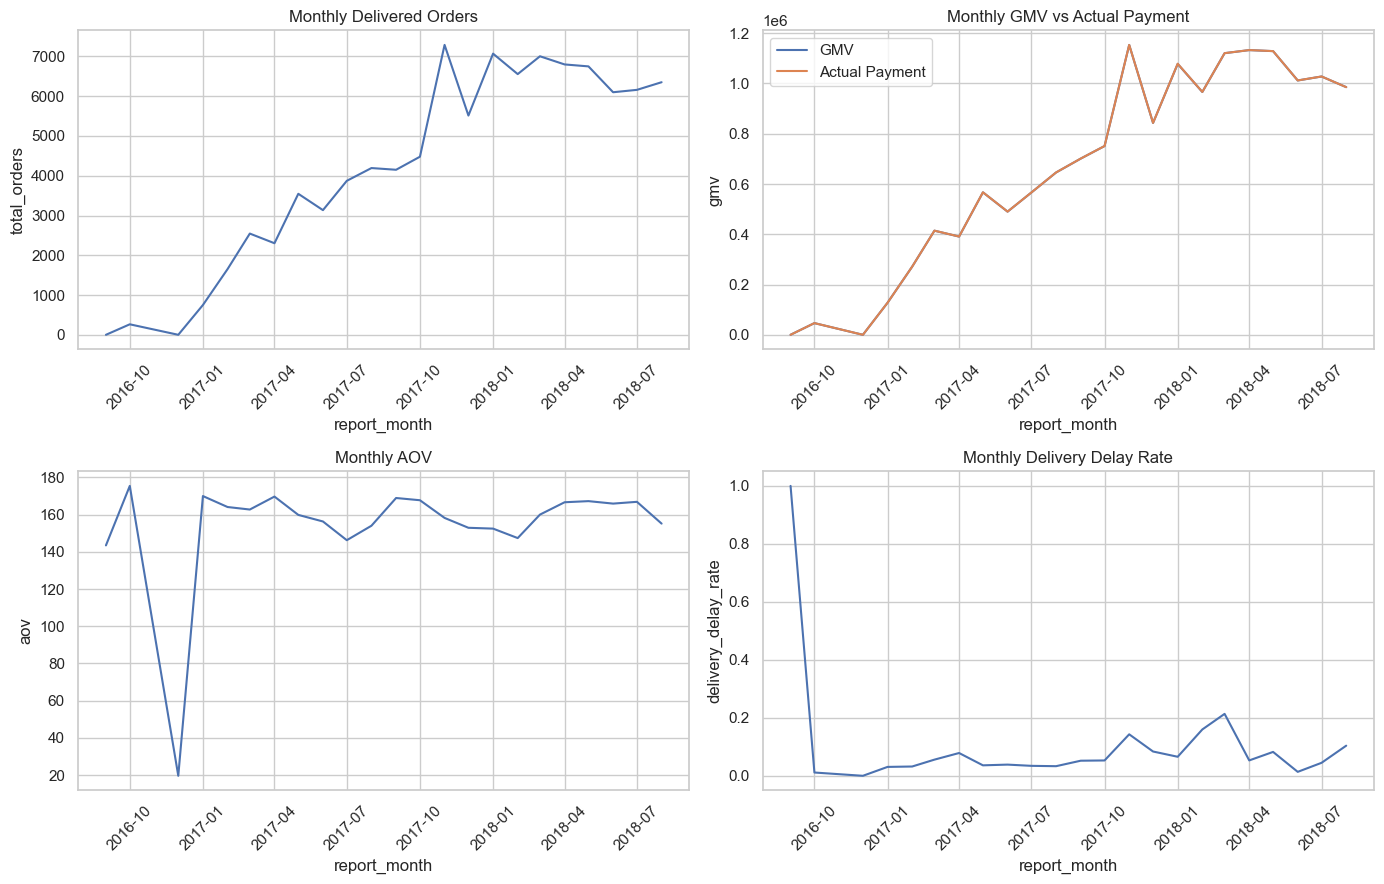

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.lineplot(data=kpi_monthly, x="report_month", y="total_orders", ax=axes[0, 0])
axes[0, 0].set_title("Monthly Delivered Orders")

sns.lineplot(data=kpi_monthly, x="report_month", y="gmv", label="GMV", ax=axes[0, 1])
sns.lineplot(data=kpi_monthly, x="report_month", y="actual_payment", label="Actual Payment", ax=axes[0, 1])
axes[0, 1].set_title("Monthly GMV vs Actual Payment")

sns.lineplot(data=kpi_monthly, x="report_month", y="aov", ax=axes[1, 0])
axes[1, 0].set_title("Monthly AOV")

sns.lineplot(data=kpi_monthly, x="report_month", y="delivery_delay_rate", ax=axes[1, 1])
axes[1, 1].set_title("Monthly Delivery Delay Rate")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3) Customer Behavior Exploration

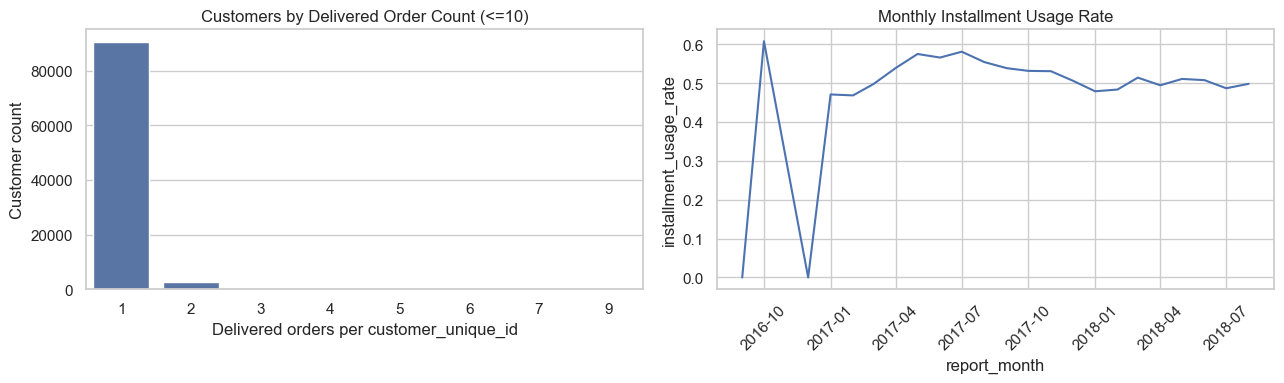

,metric,value,rate
0,one_time_customers,90557,0.969997
1,repeat_customers_gt1,2801,0.030003
2,loyal_customers_ge5,19,0.000204


In [14]:
cust_orders = (
    cust_delivered.groupby("customer_unique_id", as_index=False)
    .agg(delivered_orders=("order_id", "nunique"))
)

summary = pd.DataFrame({
    "metric": ["one_time_customers", "repeat_customers_gt1", "loyal_customers_ge5"],
    "value": [
        (cust_orders["delivered_orders"] == 1).sum(),
        (cust_orders["delivered_orders"] > 1).sum(),
        (cust_orders["delivered_orders"] >= 5).sum(),
    ],
})
summary["rate"] = summary["value"] / len(cust_orders)

order_count_dist = (
    cust_orders["delivered_orders"]
    .value_counts()
    .sort_index()
    .rename_axis("delivered_orders")
    .reset_index(name="customers")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=order_count_dist[order_count_dist["delivered_orders"] <= 10],
    x="delivered_orders",
    y="customers",
    color="#4c72b0",
    ax=axes[0],
)
axes[0].set_title("Customers by Delivered Order Count (<=10)")
axes[0].set_xlabel("Delivered orders per customer_unique_id")
axes[0].set_ylabel("Customer count")

sns.lineplot(data=kpi_monthly, x="report_month", y="installment_usage_rate", ax=axes[1])
axes[1].set_title("Monthly Installment Usage Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

summary

## 4) Revenue Exploration

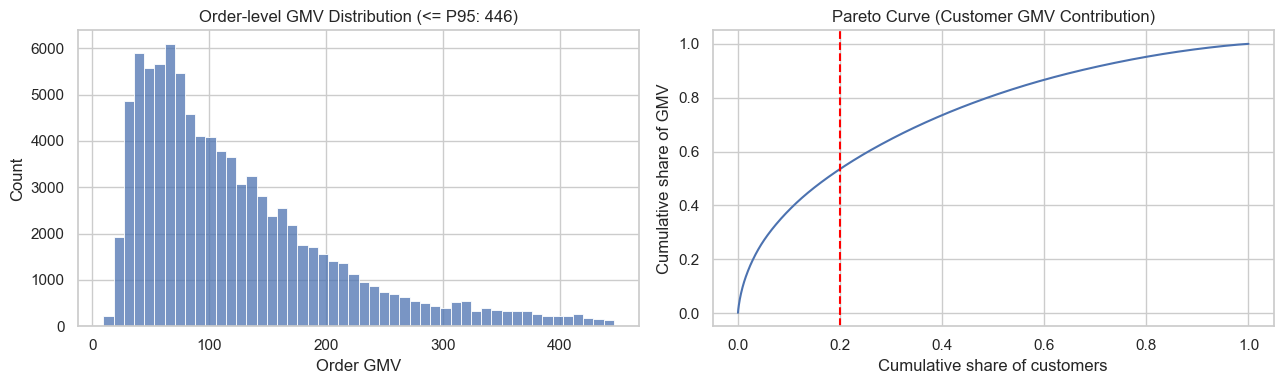

Order GMV P95: 446.23
Order GMV P99: 1,052.39
Order GMV max: 13,664.08
Top 20% customers contribute 53.52% of GMV


In [19]:
order_revenue = orders.loc[orders["is_delivered"], ["order_id", "customer_unique_id", "order_gmv"]].copy()

# Pareto must sort customers by GMV descending, then calculate cumulative shares by rank.
customer_gmv = (
    order_revenue.groupby("customer_unique_id")["order_gmv"]
    .sum()
    .sort_values(ascending=False)
)

pareto_df = pd.DataFrame({
    "customer_unique_id": customer_gmv.index,
    "customer_gmv": customer_gmv.values,
})
pareto_df["cum_gmv_pct"] = pareto_df["customer_gmv"].cumsum() / pareto_df["customer_gmv"].sum()
pareto_df["cum_customer_pct"] = np.arange(1, len(pareto_df) + 1) / len(pareto_df)

top20_cut = pareto_df.loc[pareto_df["cum_customer_pct"] <= 0.2, "customer_gmv"].sum() / pareto_df["customer_gmv"].sum()

gmv_p95 = order_revenue["order_gmv"].quantile(0.95)
gmv_p99 = order_revenue["order_gmv"].quantile(0.99)
gmv_max = order_revenue["order_gmv"].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(order_revenue.loc[order_revenue["order_gmv"] <= gmv_p95, "order_gmv"], bins=50, ax=axes[0])
axes[0].set_title(f"Order-level GMV Distribution (<= P95: {gmv_p95:,.0f})")
axes[0].set_xlabel("Order GMV")

axes[1].plot(pareto_df["cum_customer_pct"], pareto_df["cum_gmv_pct"])
axes[1].axvline(0.2, linestyle="--", color="red")
axes[1].set_title("Pareto Curve (Customer GMV Contribution)")
axes[1].set_xlabel("Cumulative share of customers")
axes[1].set_ylabel("Cumulative share of GMV")

plt.tight_layout()
plt.show()

print(f"Order GMV P95: {gmv_p95:,.2f}")
print(f"Order GMV P99: {gmv_p99:,.2f}")
print(f"Order GMV max: {gmv_max:,.2f}")
print(f"Top 20% customers contribute {top20_cut:.2%} of GMV")

## 5) Category Exploration

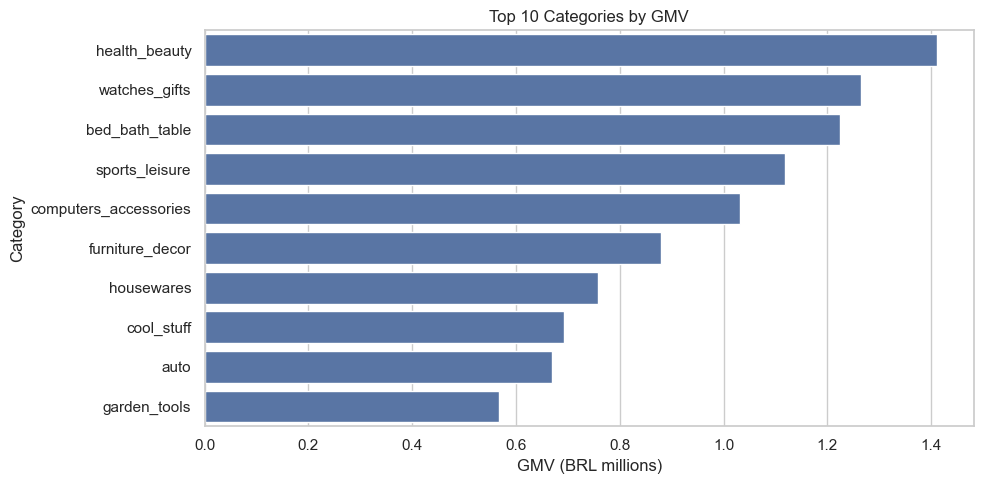

Unknown category GMV share: 0.00%


,category,total_gmv,total_orders,category_aov
43,health_beauty,"1,412,089.53","8,647",163.30
70,watches_gifts,"1,264,333.12","5,495",230.09
7,bed_bath_table,"1,225,209.26","9,272",132.14
65,sports_leisure,"1,118,256.91","7,530",148.51
15,computers_accessories,"1,032,723.77","6,530",158.15
39,furniture_decor,"880,329.92","6,307",139.58
49,housewares,"758,392.25","5,743",132.06
20,cool_stuff,"691,680.89","3,559",194.35
5,auto,"669,454.75","3,810",175.71
42,garden_tools,"567,145.68","3,448",164.49


In [21]:
cat_top = (
    cat_monthly.groupby("category", as_index=False)
    .agg(total_gmv=("category_gmv", "sum"), total_orders=("category_order_count", "sum"))
)
cat_top["category_aov"] = cat_top["total_gmv"] / cat_top["total_orders"]
cat_top["total_gmv_million"] = cat_top["total_gmv"] / 1_000_000
cat_top = cat_top.sort_values("total_gmv", ascending=False)

unknown_share = cat_top.loc[cat_top["category"] == "Unknown", "total_gmv"].sum() / cat_top["total_gmv"].sum()

plt.figure(figsize=(10, 5))
sns.barplot(data=cat_top.head(10), x="total_gmv_million", y="category")
plt.title("Top 10 Categories by GMV")
plt.xlabel("GMV (BRL millions)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

print(f"Unknown category GMV share: {unknown_share:.2%}")
(
    cat_top.head(15)[["category", "total_gmv", "total_orders", "category_aov"]]
    .style.format({
        "total_gmv": "{:,.2f}",
        "total_orders": "{:,.0f}",
        "category_aov": "{:,.2f}",
    })
)

## 6) Retention Signal Exploration

In [12]:
ret_snapshot

,as_of_date,as_of_timestamp,metric_code,total_customers,returning_customers,repeat_purchase_rate
0,2018-08-29,2018-08-29 15:00:37,last_3m_repeat_purchase,18728,214,0.011427
1,2018-08-29,2018-08-29 15:00:37,last_3m_returning_customer,18728,423,0.022587
2,2018-08-29,2018-08-29 15:00:37,last_6m_repeat_purchase,38645,637,0.016483
3,2018-08-29,2018-08-29 15:00:37,last_6m_returning_customer,38645,651,0.016846
4,2018-08-29,2018-08-29 15:00:37,lifetime_repeat_purchase,93358,2801,0.030003


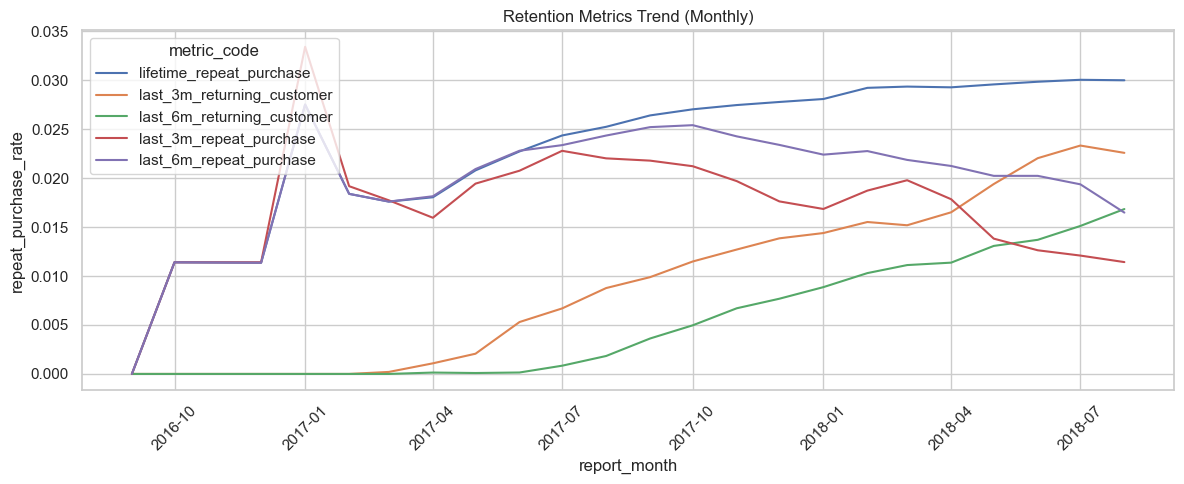

In [13]:
plt.figure(figsize=(12, 5))
plot_df = ret_monthly.copy()
plot_df["metric_code"] = pd.Categorical(
    plot_df["metric_code"],
    categories=[
        "lifetime_repeat_purchase",
        "last_3m_returning_customer",
        "last_6m_returning_customer",
        "last_3m_repeat_purchase",
        "last_6m_repeat_purchase",
    ],
    ordered=True,
)

sns.lineplot(
    data=plot_df.sort_values(["report_month", "metric_code"]),
    x="report_month",
    y="repeat_purchase_rate",
    hue="metric_code",
)
plt.title("Retention Metrics Trend (Monthly)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()